## Historical Data - US OTP

In [2]:
# import requests
# from pathlib import Path

# url = "https://transtats.bts.gov/PREZIP/On_Time_Reporting_Carrier_On_Time_Performance_1987_present_2023_1.zip"

# out = Path("data/raw/flights/otp_2023_01.zip")

# out.parent.mkdir(parents=True, exist_ok=True)

# r = requests.get(url)
# out.write_bytes(r.content)

# print("Downloaded ZIP")


In [3]:
# import zipfile

# with zipfile.ZipFile("data/raw/flights/otp_2023_01.zip", 'r') as zip_ref:
#     zip_ref.extractall("data/raw/flights")

# print("Extracted")


In [4]:
import pandas as pd

df = pd.read_csv(
    "data/raw/flights/On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2023_1.csv",
    low_memory=False
)

print(df.columns.tolist())
print(len(df))


['Year', 'Quarter', 'Month', 'DayofMonth', 'DayOfWeek', 'FlightDate', 'Reporting_Airline', 'DOT_ID_Reporting_Airline', 'IATA_CODE_Reporting_Airline', 'Tail_Number', 'Flight_Number_Reporting_Airline', 'OriginAirportID', 'OriginAirportSeqID', 'OriginCityMarketID', 'Origin', 'OriginCityName', 'OriginState', 'OriginStateFips', 'OriginStateName', 'OriginWac', 'DestAirportID', 'DestAirportSeqID', 'DestCityMarketID', 'Dest', 'DestCityName', 'DestState', 'DestStateFips', 'DestStateName', 'DestWac', 'CRSDepTime', 'DepTime', 'DepDelay', 'DepDelayMinutes', 'DepDel15', 'DepartureDelayGroups', 'DepTimeBlk', 'TaxiOut', 'WheelsOff', 'WheelsOn', 'TaxiIn', 'CRSArrTime', 'ArrTime', 'ArrDelay', 'ArrDelayMinutes', 'ArrDel15', 'ArrivalDelayGroups', 'ArrTimeBlk', 'Cancelled', 'CancellationCode', 'Diverted', 'CRSElapsedTime', 'ActualElapsedTime', 'AirTime', 'Flights', 'Distance', 'DistanceGroup', 'CarrierDelay', 'WeatherDelay', 'NASDelay', 'SecurityDelay', 'LateAircraftDelay', 'FirstDepTime', 'TotalAddGTime'

In [5]:
from pathlib import Path

bronze_path = Path("data/bronze/flights")
bronze_path.mkdir(parents=True, exist_ok=True)

In [6]:
bronze_cols = [
    "FlightDate",
    "Reporting_Airline",
    "Origin",
    "Dest",
    "CRSDepTime",
    "DepTime",
    "CRSArrTime",
    "ArrTime",
    "DepDelay",
    "ArrDelay",
    "Cancelled"
]

bronze_df = df[bronze_cols].copy()
bronze_df

,FlightDate,Reporting_Airline,Origin,Dest,CRSDepTime,DepTime,CRSArrTime,ArrTime,DepDelay,ArrDelay,Cancelled
0,2023-01-02,9E,BDL,LGA,800,757.0,905,853.0,-3.0,-12.0,0.0
1,2023-01-03,9E,BDL,LGA,800,755.0,905,857.0,-5.0,-8.0,0.0
2,2023-01-04,9E,BDL,LGA,800,755.0,905,844.0,-5.0,-21.0,0.0
3,2023-01-05,9E,BDL,LGA,800,754.0,905,848.0,-6.0,-17.0,0.0
4,2023-01-06,9E,BDL,LGA,800,759.0,905,849.0,-1.0,-16.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
538832,2023-01-02,UA,EWR,MKE,825,836.0,1001,1007.0,11.0,6.0,0.0
538833,2023-01-02,UA,DEN,LAX,745,752.0,923,939.0,7.0,16.0,0.0
538834,2023-01-02,UA,ORD,RSW,1400,1504.0,1802,1856.0,64.0,54.0,0.0
538835,2023-01-02,UA,RSW,EWR,1905,NaN,2159,NaN,NaN,NaN,1.0


In [7]:
bronze_df["FlightDate"] = pd.to_datetime(bronze_df["FlightDate"])

# Remove cancelled flights
bronze_df = bronze_df[bronze_df["Cancelled"] == 0]

bronze_df

,FlightDate,Reporting_Airline,Origin,Dest,CRSDepTime,DepTime,CRSArrTime,ArrTime,DepDelay,ArrDelay,Cancelled
0,2023-01-02,9E,BDL,LGA,800,757.0,905,853.0,-3.0,-12.0,0.0
1,2023-01-03,9E,BDL,LGA,800,755.0,905,857.0,-5.0,-8.0,0.0
2,2023-01-04,9E,BDL,LGA,800,755.0,905,844.0,-5.0,-21.0,0.0
3,2023-01-05,9E,BDL,LGA,800,754.0,905,848.0,-6.0,-17.0,0.0
4,2023-01-06,9E,BDL,LGA,800,759.0,905,849.0,-1.0,-16.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
538831,2023-01-02,UA,FLL,ORD,702,657.0,923,909.0,-5.0,-14.0,0.0
538832,2023-01-02,UA,EWR,MKE,825,836.0,1001,1007.0,11.0,6.0,0.0
538833,2023-01-02,UA,DEN,LAX,745,752.0,923,939.0,7.0,16.0,0.0
538834,2023-01-02,UA,ORD,RSW,1400,1504.0,1802,1856.0,64.0,54.0,0.0


In [8]:
# bronze_df.to_csv("data/bronze/flights/jan2023_bronze.csv", index=False)

In [9]:
print("Bronze saved:", len(bronze_df))

Bronze saved: 528542


In [10]:
bronze_df.head()

,FlightDate,Reporting_Airline,Origin,Dest,CRSDepTime,DepTime,CRSArrTime,ArrTime,DepDelay,ArrDelay,Cancelled
0,2023-01-02,9E,BDL,LGA,800,757.0,905,853.0,-3.0,-12.0,0.0
1,2023-01-03,9E,BDL,LGA,800,755.0,905,857.0,-5.0,-8.0,0.0
2,2023-01-04,9E,BDL,LGA,800,755.0,905,844.0,-5.0,-21.0,0.0
3,2023-01-05,9E,BDL,LGA,800,754.0,905,848.0,-6.0,-17.0,0.0
4,2023-01-06,9E,BDL,LGA,800,759.0,905,849.0,-1.0,-16.0,0.0


## Weather Data - OurAirports & Meteostat

- Download OurAirports dataset

In [11]:
# import requests
# from pathlib import Path

# url = "https://ourairports.com/data/airports.csv"

# out = Path("data/raw/weather/airports.csv")
# out.parent.mkdir(parents=True, exist_ok=True)

# r = requests.get(url)
# out.write_bytes(r.content)

# print("airports.csv downloaded")


In [12]:
import pandas as pd

airports_meta = pd.read_csv("data/raw/weather/airports.csv")
airports_meta.head()


,id,ident,type,name,latitude_deg,longitude_deg,elevation_ft,continent,iso_country,iso_region,municipality,scheduled_service,icao_code,iata_code,gps_code,local_code,home_link,wikipedia_link,keywords
0,6523,00A,heliport,Total RF Heliport,40.070985,-74.933689,11.0,NaN,US,US-PA,Bensalem,no,NaN,NaN,K00A,00A,https://www.penndot.pa.gov/TravelInPA/airports...,NaN,NaN
1,323361,00AA,small_airport,Aero B Ranch Airport,38.704022,-101.473911,3435.0,NaN,US,US-KS,Leoti,no,NaN,NaN,00AA,00AA,NaN,NaN,NaN
2,6524,00AK,small_airport,Lowell Field,59.947733,-151.692524,450.0,NaN,US,US-AK,Anchor Point,no,NaN,NaN,00AK,00AK,NaN,NaN,NaN
3,6525,00AL,small_airport,Epps Airpark,34.864799,-86.770302,820.0,NaN,US,US-AL,Harvest,no,NaN,NaN,00AL,00AL,NaN,NaN,NaN
4,506791,00AN,small_airport,Katmai Lodge Airport,59.093287,-156.456699,80.0,NaN,US,US-AK,King Salmon,no,NaN,NaN,00AN,00AN,NaN,NaN,NaN


- Take just airport code, latitude & longitude

In [13]:
airports_meta = airports_meta[["iata_code","latitude_deg","longitude_deg"]].dropna()

airports_meta.rename(columns={
    "iata_code": "Origin",
    "latitude_deg": "lat",
    "longitude_deg": "lon"
}, inplace=True)

airports_meta.head()


,Origin,lat,lon
204,UTK,11.222219,169.851429
410,OCA,25.325399,-80.274803
632,CSE,38.851918,-106.928341
888,CUS,31.823898,-107.629924
985,JCY,30.251801,-98.622498


- Take flight data from US OTP data and join with this data

In [14]:
flights = pd.read_csv("data/bronze/flights/jan2023_bronze.csv")
flights["FlightDate"] = pd.to_datetime(flights["FlightDate"])

flights = flights.merge(airports_meta, on="Origin", how="left")
flights.head()

,FlightDate,Reporting_Airline,Origin,Dest,CRSDepTime,DepTime,CRSArrTime,ArrTime,DepDelay,ArrDelay,Cancelled,lat,lon
0,2023-01-02,9E,BDL,LGA,800,757.0,905,853.0,-3.0,-12.0,0.0,41.938555,-72.688016
1,2023-01-03,9E,BDL,LGA,800,755.0,905,857.0,-5.0,-8.0,0.0,41.938555,-72.688016
2,2023-01-04,9E,BDL,LGA,800,755.0,905,844.0,-5.0,-21.0,0.0,41.938555,-72.688016
3,2023-01-05,9E,BDL,LGA,800,754.0,905,848.0,-6.0,-17.0,0.0,41.938555,-72.688016
4,2023-01-06,9E,BDL,LGA,800,759.0,905,849.0,-1.0,-16.0,0.0,41.938555,-72.688016


In [15]:
from meteostat import Daily, Stations
#Stations → lets you search for weather stations
#Daily → fetches daily weather data from a station
from datetime import datetime

start = datetime(2023,1,1)
end = datetime(2023,1,31)

records = []        #To store weather tables coz each airport produces its own weather dataframe

for airport in flights["Origin"].unique()[:30]:     #Later remove [:10] to scale

    row = flights[flights["Origin"] == airport].iloc[0]     #Finds first flight from this airport & stores in row coz every flight from JFK shares same coordinates. You don’t need to look at all rows.

    stations = Stations().nearby(row["lat"], row["lon"])        #Searches Meteostat database for weather stations near
    station = stations.fetch(1)     #Fetches closest single station. One station per airport is enough for daily weather

    if station.empty:       #If no station found skip this airport, skip this airport
        continue

    data = Daily(station, start, end).fetch()       #Fetch daily weather (temperature, wind, precipitation)
    data["Origin"] = airport        #Attach airport code to every weather row
    records.append(data.reset_index())

weather = pd.concat(records)        #Merges weather from all airports into ONE dataframe
weather.head()


,time,tavg,tmin,tmax,prcp,snow,wdir,wspd,wpgt,pres,tsun,Origin
0,2023-01-01,8.6,0.6,10.6,0.8,0.0,<NA>,10.8,<NA>,1010.8,<NA>,BDL
1,2023-01-02,2.9,-2.1,8.3,0.0,0.0,<NA>,3.2,<NA>,1019.0,<NA>,BDL
2,2023-01-03,1.8,-1.6,4.4,10.7,0.0,<NA>,3.6,<NA>,1015.5,<NA>,BDL
3,2023-01-04,5.2,3.9,8.3,6.6,0.0,<NA>,7.2,<NA>,1011.1,<NA>,BDL
4,2023-01-05,6.8,3.9,7.8,0.8,0.0,<NA>,13.7,<NA>,1014.8,<NA>,BDL


In [16]:
weather = weather.rename(columns={
    "time": "FlightDate",
    "tavg": "TEMP",
    "wspd": "WDSP",
    "prcp": "PRCP"
})

weather = weather[["Origin","FlightDate","TEMP","WDSP","PRCP"]]
weather.head()

,Origin,FlightDate,TEMP,WDSP,PRCP
0,BDL,2023-01-01,8.6,10.8,0.8
1,BDL,2023-01-02,2.9,3.2,0.0
2,BDL,2023-01-03,1.8,3.6,10.7
3,BDL,2023-01-04,5.2,7.2,6.6
4,BDL,2023-01-05,6.8,13.7,0.8


In [17]:
silver = flights.merge(weather, on=["Origin","FlightDate"], how="left")

In [18]:
# silver.to_csv("data/silver/jan2023_silver.csv", index=False)

In [19]:
print("Silver saved:", len(silver))

Silver saved: 528542


In [20]:
silver.head()

,FlightDate,Reporting_Airline,Origin,Dest,CRSDepTime,DepTime,CRSArrTime,ArrTime,DepDelay,ArrDelay,Cancelled,lat,lon,TEMP,WDSP,PRCP
0,2023-01-02,9E,BDL,LGA,800,757.0,905,853.0,-3.0,-12.0,0.0,41.938555,-72.688016,2.9,3.2,0.0
1,2023-01-03,9E,BDL,LGA,800,755.0,905,857.0,-5.0,-8.0,0.0,41.938555,-72.688016,1.8,3.6,10.7
2,2023-01-04,9E,BDL,LGA,800,755.0,905,844.0,-5.0,-21.0,0.0,41.938555,-72.688016,5.2,7.2,6.6
3,2023-01-05,9E,BDL,LGA,800,754.0,905,848.0,-6.0,-17.0,0.0,41.938555,-72.688016,6.8,13.7,0.8
4,2023-01-06,9E,BDL,LGA,800,759.0,905,849.0,-1.0,-16.0,0.0,41.938555,-72.688016,3.3,5.8,9.7


## Airport metadata + terminal & gate mapping

In [21]:
import pandas as pd

airports = pd.read_csv("data/raw/weather/airports.csv")

airport_meta = airports[
    ["iata_code", "name", "latitude_deg", "longitude_deg", "type"]
].dropna()

airport_meta.rename(columns={
    "iata_code": "airport",
    "latitude_deg": "lat",
    "longitude_deg": "lon"
}, inplace=True)

airport_meta.head()


,airport,name,lat,lon,type
204,UTK,Utirik Airport,11.222219,169.851429,small_airport
410,OCA,Ocean Reef Club Airport,25.325399,-80.274803,medium_airport
632,CSE,Crested Butte Airpark,38.851918,-106.928341,small_airport
888,CUS,Columbus Airport,31.823898,-107.629924,small_airport
985,JCY,LBJ Ranch Airport,30.251801,-98.622498,small_airport


In [22]:
# airport_meta.to_csv("data/silver/airport_metadata.csv", index=False)

- Attach terminal to every flight

In [23]:
import pandas as pd

silver = pd.read_csv("data/silver/jan2023_silver.csv")
silver.head()

,FlightDate,Reporting_Airline,Origin,Dest,CRSDepTime,DepTime,CRSArrTime,ArrTime,DepDelay,ArrDelay,Cancelled,lat,lon,TEMP,WDSP,PRCP
0,2023-01-02,9E,BDL,LGA,800,757.0,905,853.0,-3.0,-12.0,0.0,41.938555,-72.688016,2.9,3.2,0.0
1,2023-01-03,9E,BDL,LGA,800,755.0,905,857.0,-5.0,-8.0,0.0,41.938555,-72.688016,1.8,3.6,10.7
2,2023-01-04,9E,BDL,LGA,800,755.0,905,844.0,-5.0,-21.0,0.0,41.938555,-72.688016,5.2,7.2,6.6
3,2023-01-05,9E,BDL,LGA,800,754.0,905,848.0,-6.0,-17.0,0.0,41.938555,-72.688016,6.8,13.7,0.8
4,2023-01-06,9E,BDL,LGA,800,759.0,905,849.0,-1.0,-16.0,0.0,41.938555,-72.688016,3.3,5.8,9.7


In [24]:
terminal_map = pd.read_csv("data/raw/airports/airline_terminal_map.csv")
terminal_map.head()

,airport,airline,terminal
0,JFK,9E,4
1,JFK,AA,8
2,JFK,AS,7
3,JFK,B6,5
4,JFK,DL,4


In [25]:
silver = silver.merge(
    terminal_map,
    left_on=["Origin","Reporting_Airline"],
    right_on=["airport","airline"],
    how="left"
)
silver_jfk = silver[silver["Origin"] == "JFK"].copy()
silver_jfk.head()

,FlightDate,Reporting_Airline,Origin,Dest,CRSDepTime,DepTime,CRSArrTime,ArrTime,DepDelay,ArrDelay,Cancelled,lat,lon,TEMP,WDSP,PRCP,airport,airline,terminal
77,2023-01-08,9E,JFK,ITH,2200,2154.0,2309,2305.0,-6.0,-4.0,0.0,40.639447,-73.779317,2.9,14.8,0.0,JFK,9E,4.0
78,2023-01-09,9E,JFK,ITH,2200,2152.0,2309,2304.0,-8.0,-5.0,0.0,40.639447,-73.779317,4.2,15.8,0.5,JFK,9E,4.0
79,2023-01-10,9E,JFK,ITH,2200,2150.0,2309,2308.0,-10.0,-1.0,0.0,40.639447,-73.779317,3.8,15.5,0.0,JFK,9E,4.0
80,2023-01-11,9E,JFK,ITH,2200,2155.0,2309,2323.0,-5.0,14.0,0.0,40.639447,-73.779317,3.2,12.6,0.0,JFK,9E,4.0
81,2023-01-12,9E,JFK,ITH,2155,2321.0,2304,133.0,86.0,149.0,0.0,40.639447,-73.779317,5.5,19.1,6.9,JFK,9E,4.0


In [26]:
print(len(silver_jfk))

10837


In [27]:
# silver_jfk.to_csv("data/silver/jan2023_jfk_with_terminal.csv", index=False)

- Assign a gate (simulation)

In [28]:
layout = pd.read_csv("data/raw/airports/layouts/jfk_layout.csv")
layout.head()

,airport,terminal,gate,x,y
0,JFK,4,B1,40,40
1,JFK,4,B2,42,40
2,JFK,4,B3,44,40
3,JFK,5,C1,25,30
4,JFK,5,C2,27,30


In [29]:
import random

def assign_gate(row):
    gates = layout[
        (layout["airport"] == row["Origin"]) &
        (layout["terminal"] == row["terminal"])
    ]
    
    if gates.empty:
        return pd.Series([None,None,None])
    
    gate = gates.sample(1).iloc[0]
    return pd.Series([gate["gate"], gate["x"], gate["y"]])      #x & y are the coordinates of gates


In [30]:
silver_jfk[["gate","x","y"]] = silver_jfk.apply(assign_gate, axis=1)
silver_jfk.head()

,FlightDate,Reporting_Airline,Origin,Dest,CRSDepTime,DepTime,CRSArrTime,ArrTime,DepDelay,ArrDelay,...,lon,TEMP,WDSP,PRCP,airport,airline,terminal,gate,x,y
77,2023-01-08,9E,JFK,ITH,2200,2154.0,2309,2305.0,-6.0,-4.0,...,-73.779317,2.9,14.8,0.0,JFK,9E,4.0,B1,40,40
78,2023-01-09,9E,JFK,ITH,2200,2152.0,2309,2304.0,-8.0,-5.0,...,-73.779317,4.2,15.8,0.5,JFK,9E,4.0,B1,40,40
79,2023-01-10,9E,JFK,ITH,2200,2150.0,2309,2308.0,-10.0,-1.0,...,-73.779317,3.8,15.5,0.0,JFK,9E,4.0,B2,42,40
80,2023-01-11,9E,JFK,ITH,2200,2155.0,2309,2323.0,-5.0,14.0,...,-73.779317,3.2,12.6,0.0,JFK,9E,4.0,B3,44,40
81,2023-01-12,9E,JFK,ITH,2155,2321.0,2304,133.0,86.0,149.0,...,-73.779317,5.5,19.1,6.9,JFK,9E,4.0,B2,42,40


In [31]:
# silver_jfk.to_csv("data/silver/jan2023_jfk_with_gate.csv", index=False)


In [32]:
pd.read_csv('data/silver/jan2023_jfk_simulation.csv').head()

,FlightDate,Reporting_Airline,Origin,Dest,CRSDepTime,DepTime,CRSArrTime,ArrTime,DepDelay,ArrDelay,...,lon,TEMP,WDSP,PRCP,airport,airline,terminal,gate,x,y
0,2023-01-08,9E,JFK,ITH,2200,2154.0,2309,2305.0,-6.0,-4.0,...,-73.779317,2.9,14.8,0.0,JFK,9E,4,B2,42,40
1,2023-01-09,9E,JFK,ITH,2200,2152.0,2309,2304.0,-8.0,-5.0,...,-73.779317,4.2,15.8,0.5,JFK,9E,4,B3,44,40
2,2023-01-10,9E,JFK,ITH,2200,2150.0,2309,2308.0,-10.0,-1.0,...,-73.779317,3.8,15.5,0.0,JFK,9E,4,B2,42,40
3,2023-01-11,9E,JFK,ITH,2200,2155.0,2309,2323.0,-5.0,14.0,...,-73.779317,3.2,12.6,0.0,JFK,9E,4,B1,40,40
4,2023-01-12,9E,JFK,ITH,2155,2321.0,2304,133.0,86.0,149.0,...,-73.779317,5.5,19.1,6.9,JFK,9E,4,B3,44,40


## Feature Engineering - Delay model

- Load JFK simulation dataset

In [33]:
import pandas as pd

df = pd.read_csv("data/silver/jan2023_jfk_simulation.csv")
df["FlightDate"] = pd.to_datetime(df["FlightDate"])
df.head()

,FlightDate,Reporting_Airline,Origin,Dest,CRSDepTime,DepTime,CRSArrTime,ArrTime,DepDelay,ArrDelay,...,lon,TEMP,WDSP,PRCP,airport,airline,terminal,gate,x,y
0,2023-01-08,9E,JFK,ITH,2200,2154.0,2309,2305.0,-6.0,-4.0,...,-73.779317,2.9,14.8,0.0,JFK,9E,4,B2,42,40
1,2023-01-09,9E,JFK,ITH,2200,2152.0,2309,2304.0,-8.0,-5.0,...,-73.779317,4.2,15.8,0.5,JFK,9E,4,B3,44,40
2,2023-01-10,9E,JFK,ITH,2200,2150.0,2309,2308.0,-10.0,-1.0,...,-73.779317,3.8,15.5,0.0,JFK,9E,4,B2,42,40
3,2023-01-11,9E,JFK,ITH,2200,2155.0,2309,2323.0,-5.0,14.0,...,-73.779317,3.2,12.6,0.0,JFK,9E,4,B1,40,40
4,2023-01-12,9E,JFK,ITH,2155,2321.0,2304,133.0,86.0,149.0,...,-73.779317,5.5,19.1,6.9,JFK,9E,4,B3,44,40


- Basic time features

In [34]:
df["hour"] = df["CRSDepTime"] // 100
df["day_of_week"] = df["FlightDate"].dt.dayofweek
df["is_weekend"] = df["day_of_week"].isin([5,6]).astype(int)

- Weather severity score

In [35]:
#Models work better with aggregated causal indicators
df["weather_severity"] = (
    df["PRCP"].fillna(0) * 2 +      # x2 coz rain causes more impact on delay
    df["WDSP"].fillna(0) * 0.5      # 0.5 coz compared to precipitaion or rain, impact is lower. High wind still increases severity. Just not as aggressively as rain
)       

- Historical congestion proxy

In [36]:
#Schedule-driven congestion - gives How many flights usually happen at this hour
df["flight_hour"] = df["hour"]

hourly_counts = (
    df.groupby("flight_hour")
      .size()
      .rename("hourly_flight_volume")
)

df = df.join(hourly_counts, on="flight_hour")
df.head()

,FlightDate,Reporting_Airline,Origin,Dest,CRSDepTime,DepTime,CRSArrTime,ArrTime,DepDelay,ArrDelay,...,terminal,gate,x,y,hour,day_of_week,is_weekend,weather_severity,flight_hour,hourly_flight_volume
0,2023-01-08,9E,JFK,ITH,2200,2154.0,2309,2305.0,-6.0,-4.0,...,4,B2,42,40,22,6,1,7.40,22,337
1,2023-01-09,9E,JFK,ITH,2200,2152.0,2309,2304.0,-8.0,-5.0,...,4,B3,44,40,22,0,0,8.90,22,337
2,2023-01-10,9E,JFK,ITH,2200,2150.0,2309,2308.0,-10.0,-1.0,...,4,B2,42,40,22,1,0,7.75,22,337
3,2023-01-11,9E,JFK,ITH,2200,2155.0,2309,2323.0,-5.0,14.0,...,4,B1,40,40,22,2,0,6.30,22,337
4,2023-01-12,9E,JFK,ITH,2155,2321.0,2304,133.0,86.0,149.0,...,4,B3,44,40,21,3,0,23.35,21,541


- Rolling delay at airport

In [37]:
#Recent operational health - What’s the average delay of recent flights?
df = df.sort_values("FlightDate")       #sorted so that rolling statistics only see past flights

df["rolling_origin_delay"] = (
    df["DepDelay"]
    .rolling(window=200, min_periods=20)        #Takes the delay of the last 200 flights and wait until there are atleast 20 flights
    .mean()
)


- Previous flight delay

In [38]:
df["prev_delay"] = df["DepDelay"].shift(1)      #delay of the immediately previous flight in time

- Target variable

In [39]:
#Industry standard - 15 minutes = delayed
df["is_delayed"] = (df["ArrDelay"] > 15).astype(int)

- Select final feature set

In [40]:
features = [
    "hour",
    "day_of_week",
    "is_weekend",
    "weather_severity",
    "hourly_flight_volume",
    "rolling_origin_delay",
    "prev_delay"
]

target = "is_delayed"

gold = df[features + [target]].dropna()
gold.head()

,hour,day_of_week,is_weekend,weather_severity,hourly_flight_volume,rolling_origin_delay,prev_delay,is_delayed
1335,14,6,1,8.1,649,18.950000,-7.0,0
3108,16,6,1,8.1,637,17.761905,19.0,0
382,21,6,1,8.1,541,16.727273,-6.0,0
3107,21,6,1,8.1,541,18.130435,-5.0,1
3111,23,6,1,8.1,11,17.083333,49.0,0


- Save Gold dataset

In [41]:
# gold.to_csv("data/gold/jfk_delay_features.csv", index=False)
# print("Gold dataset saved:", len(gold))

## Feature Engineering - Congestion Model

- Load JFK simulation dataset

In [42]:
import pandas as pd
import numpy as np

df = pd.read_csv("data/silver/jan2023_jfk_simulation.csv")
df["FlightDate"] = pd.to_datetime(df["FlightDate"])
df.head()

,FlightDate,Reporting_Airline,Origin,Dest,CRSDepTime,DepTime,CRSArrTime,ArrTime,DepDelay,ArrDelay,...,lon,TEMP,WDSP,PRCP,airport,airline,terminal,gate,x,y
0,2023-01-08,9E,JFK,ITH,2200,2154.0,2309,2305.0,-6.0,-4.0,...,-73.779317,2.9,14.8,0.0,JFK,9E,4,B2,42,40
1,2023-01-09,9E,JFK,ITH,2200,2152.0,2309,2304.0,-8.0,-5.0,...,-73.779317,4.2,15.8,0.5,JFK,9E,4,B3,44,40
2,2023-01-10,9E,JFK,ITH,2200,2150.0,2309,2308.0,-10.0,-1.0,...,-73.779317,3.8,15.5,0.0,JFK,9E,4,B2,42,40
3,2023-01-11,9E,JFK,ITH,2200,2155.0,2309,2323.0,-5.0,14.0,...,-73.779317,3.2,12.6,0.0,JFK,9E,4,B1,40,40
4,2023-01-12,9E,JFK,ITH,2155,2321.0,2304,133.0,86.0,149.0,...,-73.779317,5.5,19.1,6.9,JFK,9E,4,B3,44,40


In [43]:
df["hour"] = df["CRSDepTime"] // 100
df["flight_hour"] = df["hour"]

In [44]:
hourly_counts = (
    df.groupby("flight_hour")
      .size()
      .rename("hourly_flight_volume")
)

df = df.join(hourly_counts, on="flight_hour")


- Time-of-day congestion (already partially done). Just Normalize to 0–1

In [45]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df["time_congestion"] = scaler.fit_transform(
    df[["hourly_flight_volume"]]
)
#0 -> queit hours
#1 -> peak hours

- Terminal congestion

In [46]:
#Count flights per terminal per hour
terminal_hour = (
    df.groupby(["terminal","hour"])
      .size()
      .rename("terminal_flights")
      .reset_index()
)

In [47]:
terminal_hour.head()

,terminal,hour,terminal_flights
0,4,6,83
1,4,7,331
2,4,8,416
3,4,9,278
4,4,10,162


In [48]:
#Join back 
df = df.merge(terminal_hour, on=["terminal","hour"], how="left")
df.head()
#Gives how many flights are happening in my terminal at this hour

,FlightDate,Reporting_Airline,Origin,Dest,CRSDepTime,DepTime,CRSArrTime,ArrTime,DepDelay,ArrDelay,...,airline,terminal,gate,x,y,hour,flight_hour,hourly_flight_volume,time_congestion,terminal_flights
0,2023-01-08,9E,JFK,ITH,2200,2154.0,2309,2305.0,-6.0,-4.0,...,9E,4,B2,42,40,22,22,337,0.346072,106
1,2023-01-09,9E,JFK,ITH,2200,2152.0,2309,2304.0,-8.0,-5.0,...,9E,4,B3,44,40,22,22,337,0.346072,106
2,2023-01-10,9E,JFK,ITH,2200,2150.0,2309,2308.0,-10.0,-1.0,...,9E,4,B2,42,40,22,22,337,0.346072,106
3,2023-01-11,9E,JFK,ITH,2200,2155.0,2309,2323.0,-5.0,14.0,...,9E,4,B1,40,40,22,22,337,0.346072,106
4,2023-01-12,9E,JFK,ITH,2155,2321.0,2304,133.0,86.0,149.0,...,9E,4,B3,44,40,21,21,541,0.562633,195


In [49]:
scaler = MinMaxScaler()

df["terminal_congestion"] = scaler.fit_transform(
    df[["terminal_flights"]]
)

In [50]:
df.head()

,FlightDate,Reporting_Airline,Origin,Dest,CRSDepTime,DepTime,CRSArrTime,ArrTime,DepDelay,ArrDelay,...,terminal,gate,x,y,hour,flight_hour,hourly_flight_volume,time_congestion,terminal_flights,terminal_congestion
0,2023-01-08,9E,JFK,ITH,2200,2154.0,2309,2305.0,-6.0,-4.0,...,4,B2,42,40,22,22,337,0.346072,106,0.228261
1,2023-01-09,9E,JFK,ITH,2200,2152.0,2309,2304.0,-8.0,-5.0,...,4,B3,44,40,22,22,337,0.346072,106,0.228261
2,2023-01-10,9E,JFK,ITH,2200,2150.0,2309,2308.0,-10.0,-1.0,...,4,B2,42,40,22,22,337,0.346072,106,0.228261
3,2023-01-11,9E,JFK,ITH,2200,2155.0,2309,2323.0,-5.0,14.0,...,4,B1,40,40,22,22,337,0.346072,106,0.228261
4,2023-01-12,9E,JFK,ITH,2155,2321.0,2304,133.0,86.0,149.0,...,4,B3,44,40,21,21,541,0.562633,195,0.421739


- Spatial congestion

In [51]:
df[['x','y']].values

array([[42, 40],
       [44, 40],
       [42, 40],
       ...,
       [14, 10],
       [14, 10],
       [14, 10]], shape=(10837, 2))

In [52]:
#Simple density proxy - Calculates how crowded each gate area is
coords = df[["x","y"]].values       #Each row -> one flight’s gate position

density = []        #stores number of nearby flights

for i in range(len(coords)):        #loop over every flight
    d = np.sqrt(((coords - coords[i])**2).sum(axis=1))      #Compute distances from flight i to all others - Euclidean distance formula
    density.append((d < 8).sum())   # Count neighbors inside radius

In [53]:
df["spatial_density"] = density
#Gives how many flights are within ~8 units of this gate.

In [54]:
scaler = MinMaxScaler()

df["spatial_congestion"] = scaler.fit_transform(
    df[["spatial_density"]]
)
df

,FlightDate,Reporting_Airline,Origin,Dest,CRSDepTime,DepTime,CRSArrTime,ArrTime,DepDelay,ArrDelay,...,x,y,hour,flight_hour,hourly_flight_volume,time_congestion,terminal_flights,terminal_congestion,spatial_density,spatial_congestion
0,2023-01-08,9E,JFK,ITH,2200,2154.0,2309,2305.0,-6.0,-4.0,...,42,40,22,22,337,0.346072,106,0.228261,3929,1.00000
1,2023-01-09,9E,JFK,ITH,2200,2152.0,2309,2304.0,-8.0,-5.0,...,44,40,22,22,337,0.346072,106,0.228261,3929,1.00000
2,2023-01-10,9E,JFK,ITH,2200,2150.0,2309,2308.0,-10.0,-1.0,...,42,40,22,22,337,0.346072,106,0.228261,3929,1.00000
3,2023-01-11,9E,JFK,ITH,2200,2155.0,2309,2323.0,-5.0,14.0,...,40,40,22,22,337,0.346072,106,0.228261,3929,1.00000
4,2023-01-12,9E,JFK,ITH,2155,2321.0,2304,133.0,86.0,149.0,...,44,40,21,21,541,0.562633,195,0.421739,3929,1.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10832,2023-01-31,OO,JFK,IAD,1559,1812.0,1729,1935.0,133.0,126.0,...,14,10,15,15,892,0.935244,325,0.704348,2830,0.69948
10833,2023-01-11,OO,JFK,BNA,900,919.0,1046,1052.0,19.0,6.0,...,14,10,9,9,929,0.974522,230,0.497826,2830,0.69948
10834,2023-01-11,OO,JFK,ORD,1600,1606.0,1807,1740.0,6.0,-27.0,...,14,10,16,16,637,0.664544,168,0.363043,2830,0.69948
10835,2023-01-12,OO,JFK,ORD,1600,1606.0,1807,1809.0,6.0,2.0,...,14,10,16,16,637,0.664544,168,0.363043,2830,0.69948


- Combine into unified congestion score

In [55]:
df["congestion_score"] = (
    df["time_congestion"] * 0.4 +
    df["terminal_congestion"] * 0.35 +
    df["spatial_congestion"] * 0.25
)
#time = strongest driver
#terminal = local pressure
#spatial = gate clustering

- Save Gold congestion dataset

In [56]:
# cols = [
#     "hour",
#     "terminal",
#     "x","y",
#     "time_congestion",
#     "terminal_congestion",
#     "spatial_congestion",
#     "congestion_score"
# ]

# df[cols].to_csv("data/gold/jfk_congestion_features.csv", index=False)

# print("Congestion gold dataset saved")

## Feature Engineering - Buffer / Re-entry Time (Extra Safety time added on top of others)

- Load delay features + congestion features

In [74]:
import pandas as pd

delay = pd.read_csv("data/gold/jfk_delay_features.csv")
delay.head()

,hour,day_of_week,is_weekend,weather_severity,hourly_flight_volume,rolling_origin_delay,prev_delay,is_delayed
0,14,6,1,8.1,649,18.950000,15.0,0
1,16,6,1,8.1,637,17.761905,49.0,0
2,21,6,1,8.1,541,16.727273,161.0,0
3,21,6,1,8.1,541,18.130435,-2.0,1
4,23,6,1,8.1,11,17.083333,-5.0,0


In [75]:
congestion = pd.read_csv("data/gold/jfk_congestion_features.csv")
congestion.head()

,hour,terminal,x,y,time_congestion,terminal_congestion,spatial_congestion,congestion_score
0,22,4,42,40,0.346072,0.228261,1.0,0.468320
1,22,4,44,40,0.346072,0.228261,1.0,0.468320
2,22,4,42,40,0.346072,0.228261,1.0,0.468320
3,22,4,40,40,0.346072,0.228261,1.0,0.468320
4,21,4,44,40,0.562633,0.421739,1.0,0.622662


- Merge them

In [76]:
full = delay.merge(
    congestion,
    on=["hour"],     # you can also include terminal if present
    how="inner"
)
full.head()

,hour,day_of_week,is_weekend,weather_severity,hourly_flight_volume,rolling_origin_delay,prev_delay,is_delayed,terminal,x,y,time_congestion,terminal_congestion,spatial_congestion,congestion_score
0,14,6,1,8.1,649,18.95,15.0,0,4,42,40,0.677282,0.528261,1.0,0.705804
1,14,6,1,8.1,649,18.95,15.0,0,4,42,40,0.677282,0.528261,1.0,0.705804
2,14,6,1,8.1,649,18.95,15.0,0,4,44,40,0.677282,0.528261,1.0,0.705804
3,14,6,1,8.1,649,18.95,15.0,0,4,40,40,0.677282,0.528261,1.0,0.705804
4,14,6,1,8.1,649,18.95,15.0,0,4,42,40,0.677282,0.528261,1.0,0.705804


In [71]:
BASE_BUFFER = 15   # minutes
#Min buffer, means, Even in perfect conditions, don’t plan tighter than 15 mins

- Congestion penalty

In [77]:
full["congestion_penalty"] = full["congestion_score"] * 25
full.head()

,hour,day_of_week,is_weekend,weather_severity,hourly_flight_volume,rolling_origin_delay,prev_delay,is_delayed,terminal,x,y,time_congestion,terminal_congestion,spatial_congestion,congestion_score,congestion_penalty
0,14,6,1,8.1,649,18.95,15.0,0,4,42,40,0.677282,0.528261,1.0,0.705804,17.645106
1,14,6,1,8.1,649,18.95,15.0,0,4,42,40,0.677282,0.528261,1.0,0.705804,17.645106
2,14,6,1,8.1,649,18.95,15.0,0,4,44,40,0.677282,0.528261,1.0,0.705804,17.645106
3,14,6,1,8.1,649,18.95,15.0,0,4,40,40,0.677282,0.528261,1.0,0.705804,17.645106
4,14,6,1,8.1,649,18.95,15.0,0,4,42,40,0.677282,0.528261,1.0,0.705804,17.645106


- Operational instability penalty (from rolling delay)

In [ ]:
#One delay causes another delay, like delay of one flight cause buffer for next 

full["ops_penalty"] = full["rolling_origin_delay"].clip(lower=0) * 0.3
full.head()
#10 min → +3 min buffer. Negative delays are clipped to 0(early departures don’t reduce safety)

,hour,day_of_week,is_weekend,weather_severity,hourly_flight_volume,rolling_origin_delay,prev_delay,is_delayed,terminal,x,y,time_congestion,terminal_congestion,spatial_congestion,congestion_score,congestion_penalty,ops_penalty,buffer_minutes
0,14,6,1,8.1,649,18.95,15.0,0,4,42,40,0.677282,0.528261,1.0,0.705804,17.645106,5.685,38.330106
1,14,6,1,8.1,649,18.95,15.0,0,4,42,40,0.677282,0.528261,1.0,0.705804,17.645106,5.685,38.330106
2,14,6,1,8.1,649,18.95,15.0,0,4,44,40,0.677282,0.528261,1.0,0.705804,17.645106,5.685,38.330106
3,14,6,1,8.1,649,18.95,15.0,0,4,40,40,0.677282,0.528261,1.0,0.705804,17.645106,5.685,38.330106
4,14,6,1,8.1,649,18.95,15.0,0,4,42,40,0.677282,0.528261,1.0,0.705804,17.645106,5.685,38.330106


- Combine into buffer_minutes

In [79]:
full["buffer_minutes"] = (
    BASE_BUFFER +
    full["congestion_penalty"] +
    full["ops_penalty"]
)
full.head()

,hour,day_of_week,is_weekend,weather_severity,hourly_flight_volume,rolling_origin_delay,prev_delay,is_delayed,terminal,x,y,time_congestion,terminal_congestion,spatial_congestion,congestion_score,congestion_penalty,ops_penalty,buffer_minutes
0,14,6,1,8.1,649,18.95,15.0,0,4,42,40,0.677282,0.528261,1.0,0.705804,17.645106,5.685,38.330106
1,14,6,1,8.1,649,18.95,15.0,0,4,42,40,0.677282,0.528261,1.0,0.705804,17.645106,5.685,38.330106
2,14,6,1,8.1,649,18.95,15.0,0,4,44,40,0.677282,0.528261,1.0,0.705804,17.645106,5.685,38.330106
3,14,6,1,8.1,649,18.95,15.0,0,4,40,40,0.677282,0.528261,1.0,0.705804,17.645106,5.685,38.330106
4,14,6,1,8.1,649,18.95,15.0,0,4,42,40,0.677282,0.528261,1.0,0.705804,17.645106,5.685,38.330106


- Cap extreme values

In [ ]:
full["buffer_minutes"] = full["buffer_minutes"].clip(upper=60)
full.head()
#max buffer = 60mins

,hour,day_of_week,is_weekend,weather_severity,hourly_flight_volume,rolling_origin_delay,prev_delay,is_delayed,terminal,x,y,time_congestion,terminal_congestion,spatial_congestion,congestion_score,congestion_penalty,ops_penalty,buffer_minutes
0,14,6,1,8.1,649,18.95,15.0,0,4,42,40,0.677282,0.528261,1.0,0.705804,17.645106,5.685,38.330106
1,14,6,1,8.1,649,18.95,15.0,0,4,42,40,0.677282,0.528261,1.0,0.705804,17.645106,5.685,38.330106
2,14,6,1,8.1,649,18.95,15.0,0,4,44,40,0.677282,0.528261,1.0,0.705804,17.645106,5.685,38.330106
3,14,6,1,8.1,649,18.95,15.0,0,4,40,40,0.677282,0.528261,1.0,0.705804,17.645106,5.685,38.330106
4,14,6,1,8.1,649,18.95,15.0,0,4,42,40,0.677282,0.528261,1.0,0.705804,17.645106,5.685,38.330106


- Save Gold buffer dataset

In [ ]:
# from pathlib import Path
# Path("data/gold").mkdir(exist_ok=True)

# full[[
#     "hour",
#     "terminal",
#     "x","y",
#     "congestion_score",
#     "rolling_origin_delay",
#     "buffer_minutes"
# ]].to_csv("data/gold/jfk_buffer_features.csv", index=False)

# print("Buffer gold dataset saved")


Buffer gold dataset saved


## Train delay model

In [178]:
import pandas as pd
import joblib

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from xgboost import XGBClassifier

In [179]:
df = pd.read_csv("data/gold/jfk_delay_features.csv")

X = df.drop(columns=["is_delayed"])
y = df["is_delayed"]

X.head()


,hour,day_of_week,is_weekend,weather_severity,rolling_origin_delay,prev_delay
0,14,6,1,8.1,18.950000,-7.0
1,16,6,1,8.1,17.761905,19.0
2,21,6,1,8.1,16.727273,-6.0
3,21,6,1,8.1,18.130435,-5.0
4,23,6,1,8.1,17.083333,49.0


In [180]:
# Time-based holdout
split = int(len(X)*0.8)

X_train = X.iloc[:split]
y_train = y.iloc[:split]

X_test = X.iloc[split:]
y_test = y.iloc[split:]

In [181]:
models = {

    "logistic": (
        LogisticRegression(max_iter=1000),
        {"model__C":[0.1,1,10]}
    ),

    "random_forest": (
        RandomForestClassifier(),
        {"model__n_estimators":[100,200]}
    ),

    "gradient_boosting": (
        GradientBoostingClassifier(),
        {"model__n_estimators":[100,200]}
    ),

    "svm": (
        SVC(probability=True),
        {"model__C":[0.5,1]}
    ),

    "knn": (
        KNeighborsClassifier(),
        {"model__n_neighbors":[5,10]}
    ),

    "xgboost": (
        XGBClassifier(eval_metric="logloss"),
        {"model__max_depth":[3,5],
         "model__n_estimators":[150,250]}
    )
}


In [182]:
results = []

trained_models = {}

for name,(model,params) in models.items():

    pipe = Pipeline([
        ("scaler",StandardScaler()),
        ("model",model)
    ])

    grid = GridSearchCV(
        pipe,
        params,
        scoring="roc_auc",
        n_jobs=-1
    )

    grid.fit(X_train,y_train)

    best = grid.best_estimator_

    preds = best.predict_proba(X_test)[:,1]
    auc = roc_auc_score(y_test,preds)

    trained_models[name] = best
    results.append((name,auc))

    print(f"{name} AUC:",auc)


logistic AUC: 0.5776174005172791
random_forest AUC: 0.5916736779782494
gradient_boosting AUC: 0.5958486803153532
svm AUC: 0.5204848711476738
knn AUC: 0.578178305443894
xgboost AUC: 0.5971780249914306


In [183]:
results_df = pd.DataFrame(results,columns=["model","auc"]).sort_values("auc",ascending=False)
results_df


,model,auc
5,xgboost,0.597178
2,gradient_boosting,0.595849
1,random_forest,0.591674
4,knn,0.578178
0,logistic,0.577617
3,svm,0.520485


In [184]:
from sklearn.metrics import accuracy_score

# Convert probabilities → class labels (0/1)
y_pred = (preds > 0.5).astype(int)

acc = accuracy_score(y_test, y_pred)

print("ROC AUC:", auc)
print("Accuracy:", acc)


ROC AUC: 0.5971780249914306
Accuracy: 0.7712569316081331


## Improve AUC

In [185]:
import pandas as pd

df = pd.read_csv("data/silver/jan2023_jfk_simulation.csv")
df["FlightDate"] = pd.to_datetime(df["FlightDate"])
df.head()

,FlightDate,Reporting_Airline,Origin,Dest,CRSDepTime,DepTime,CRSArrTime,ArrTime,DepDelay,ArrDelay,...,lon,TEMP,WDSP,PRCP,airport,airline,terminal,gate,x,y
0,2023-01-08,9E,JFK,ITH,2200,2154.0,2309,2305.0,-6.0,-4.0,...,-73.779317,2.9,14.8,0.0,JFK,9E,4,B2,42,40
1,2023-01-09,9E,JFK,ITH,2200,2152.0,2309,2304.0,-8.0,-5.0,...,-73.779317,4.2,15.8,0.5,JFK,9E,4,B3,44,40
2,2023-01-10,9E,JFK,ITH,2200,2150.0,2309,2308.0,-10.0,-1.0,...,-73.779317,3.8,15.5,0.0,JFK,9E,4,B2,42,40
3,2023-01-11,9E,JFK,ITH,2200,2155.0,2309,2323.0,-5.0,14.0,...,-73.779317,3.2,12.6,0.0,JFK,9E,4,B1,40,40
4,2023-01-12,9E,JFK,ITH,2155,2321.0,2304,133.0,86.0,149.0,...,-73.779317,5.5,19.1,6.9,JFK,9E,4,B3,44,40


- Average airline delay

In [186]:
carrier_avg = (
    df.groupby("Reporting_Airline")["ArrDelay"]
      .mean()
      .rename("carrier_avg_delay")
)

df = df.join(carrier_avg, on="Reporting_Airline")
df.head()

,FlightDate,Reporting_Airline,Origin,Dest,CRSDepTime,DepTime,CRSArrTime,ArrTime,DepDelay,ArrDelay,...,TEMP,WDSP,PRCP,airport,airline,terminal,gate,x,y,carrier_avg_delay
0,2023-01-08,9E,JFK,ITH,2200,2154.0,2309,2305.0,-6.0,-4.0,...,2.9,14.8,0.0,JFK,9E,4,B2,42,40,14.661911
1,2023-01-09,9E,JFK,ITH,2200,2152.0,2309,2304.0,-8.0,-5.0,...,4.2,15.8,0.5,JFK,9E,4,B3,44,40,14.661911
2,2023-01-10,9E,JFK,ITH,2200,2150.0,2309,2308.0,-10.0,-1.0,...,3.8,15.5,0.0,JFK,9E,4,B2,42,40,14.661911
3,2023-01-11,9E,JFK,ITH,2200,2155.0,2309,2323.0,-5.0,14.0,...,3.2,12.6,0.0,JFK,9E,4,B1,40,40,14.661911
4,2023-01-12,9E,JFK,ITH,2155,2321.0,2304,133.0,86.0,149.0,...,5.5,19.1,6.9,JFK,9E,4,B3,44,40,14.661911


- Add route average delay

In [187]:
df["route"] = df["Origin"] + "_" + df["Dest"]   #delay often happens on city pairs

route_avg = (
    df.groupby("route")["ArrDelay"]   #group flights by route and computes mean of arrival delay
      .mean()
      .rename("route_avg_delay")
)

df = df.join(route_avg, on="route")


In [188]:
df.head()

,FlightDate,Reporting_Airline,Origin,Dest,CRSDepTime,DepTime,CRSArrTime,ArrTime,DepDelay,ArrDelay,...,PRCP,airport,airline,terminal,gate,x,y,carrier_avg_delay,route,route_avg_delay
0,2023-01-08,9E,JFK,ITH,2200,2154.0,2309,2305.0,-6.0,-4.0,...,0.0,JFK,9E,4,B2,42,40,14.661911,JFK_ITH,21.177778
1,2023-01-09,9E,JFK,ITH,2200,2152.0,2309,2304.0,-8.0,-5.0,...,0.5,JFK,9E,4,B3,44,40,14.661911,JFK_ITH,21.177778
2,2023-01-10,9E,JFK,ITH,2200,2150.0,2309,2308.0,-10.0,-1.0,...,0.0,JFK,9E,4,B2,42,40,14.661911,JFK_ITH,21.177778
3,2023-01-11,9E,JFK,ITH,2200,2155.0,2309,2323.0,-5.0,14.0,...,0.0,JFK,9E,4,B1,40,40,14.661911,JFK_ITH,21.177778
4,2023-01-12,9E,JFK,ITH,2155,2321.0,2304,133.0,86.0,149.0,...,6.9,JFK,9E,4,B3,44,40,14.661911,JFK_ITH,21.177778


- Add rolling weather severity

In [189]:
df["weather_severity"] = df["PRCP"].fillna(0)*2 + df["WDSP"].fillna(0)*0.5      #Already done

df = df.sort_values("FlightDate")
df["rolling_weather"] = (
    df["weather_severity"]
    .rolling(window=200, min_periods=20)
    .mean()
)


In [190]:
df.head()

,FlightDate,Reporting_Airline,Origin,Dest,CRSDepTime,DepTime,CRSArrTime,ArrTime,DepDelay,ArrDelay,...,airline,terminal,gate,x,y,carrier_avg_delay,route,route_avg_delay,weather_severity,rolling_weather
3178,2023-01-01,B6,JFK,TPA,645,703.0,951,1019.0,18.0,28.0,...,B6,5,C2,27,30,7.903481,JFK_TPA,12.581818,8.1,NaN
3174,2023-01-01,B6,JFK,MIA,651,716.0,1013,1023.0,25.0,10.0,...,B6,5,C2,27,30,7.903481,JFK_MIA,1.609259,8.1,NaN
9852,2023-01-01,YX,JFK,PIT,1529,1545.0,1716,1713.0,16.0,-3.0,...,YX,8,A1,10,10,-0.728966,JFK_PIT,0.135338,8.1,NaN
3116,2023-01-01,B6,JFK,SJU,800,817.0,1256,1301.0,17.0,5.0,...,B6,5,C1,25,30,7.903481,JFK_SJU,1.286219,8.1,NaN
7032,2023-01-01,DL,JFK,SFO,1005,1008.0,1358,1347.0,3.0,-11.0,...,DL,4,B3,44,40,3.589113,JFK_SFO,-9.202186,8.1,NaN


- bring congestion scores

In [191]:
congestion = pd.read_csv("data/gold/jfk_congestion_features.csv")

df["congestion_score"] = congestion["congestion_score"].values


- rebuild delay gold

In [192]:
df["hour"] = df["CRSDepTime"] // 100
df["day_of_week"] = df["FlightDate"].dt.dayofweek
df["is_weekend"] = df["day_of_week"].isin([5,6]).astype(int)

df["rolling_origin_delay"] = (
    df["DepDelay"]
    .rolling(window=200, min_periods=20)
    .mean()
)

df["prev_delay"] = df["DepDelay"].shift(1)
df["is_delayed"] = (df["ArrDelay"] > 15).astype(int)




In [ ]:
# features = [
#     "hour","day_of_week","is_weekend",
#     "carrier_avg_delay",
#     "route_avg_delay",
#     "weather_severity",
#     "rolling_weather",
#     "congestion_score",
#     "rolling_origin_delay",
#     "prev_delay"
# ]

# gold = df[features + ["is_delayed"]].dropna()
# gold.to_csv("data/gold/jfk_delay_features_v2.csv", index=False)

- Retrain

In [194]:
df = pd.read_csv("data/gold/jfk_delay_features_v2.csv")

X = df.drop(columns=["is_delayed"])
y = df["is_delayed"]

split = int(len(X)*0.8)

X_train = X.iloc[:split]
y_train = y.iloc[:split]
X_test = X.iloc[split:]
y_test = y.iloc[split:]

pipe = Pipeline([
    ("scaler",StandardScaler()),
    ("model",XGBClassifier(
        max_depth=3,
        n_estimators=150,
        eval_metric="logloss"
    ))
])

pipe.fit(X_train,y_train)

preds = pipe.predict_proba(X_test)[:,1]
roc_auc_score(y_test,preds)


0.6023395967716805

In [195]:
from sklearn.metrics import accuracy_score

# Convert probabilities → class labels (0/1)
y_pred = (preds > 0.5).astype(int)

acc = accuracy_score(y_test, y_pred)

print("ROC AUC:", auc)
print("Accuracy:", acc)


ROC AUC: 0.5971780249914306
Accuracy: 0.7754158964879853


## Calibration

In [196]:
import pandas as pd
import joblib
import numpy as np

from sklearn.metrics import roc_auc_score, brier_score_loss
from sklearn.calibration import calibration_curve

df = pd.read_csv("data/gold/jfk_delay_features_v2.csv")

X = df.drop(columns=["is_delayed"])
y = df["is_delayed"]

split = int(len(X)*0.8)

X_test = X.iloc[split:]
y_test = y.iloc[split:]

raw_model = joblib.load("models/champion_delay_model.pkl")
cal_model = joblib.load("models/champion_delay_model_calibrated.pkl")


In [197]:
raw_probs = raw_model.predict_proba(X_test)[:,1]
cal_probs = cal_model.predict_proba(X_test)[:,1]

print("Raw Brier:", brier_score_loss(y_test, raw_probs))
print("Calibrated Brier:", brier_score_loss(y_test, cal_probs))

print("Raw AUC:", roc_auc_score(y_test, raw_probs))
print("Calibrated AUC:", roc_auc_score(y_test, cal_probs))


Raw Brier: 0.18101425917193775
Calibrated Brier: 0.18867426055382172
Raw AUC: 0.6023395967716805
Calibrated AUC: 0.6023395967716805


In [ ]:
#Calibration did not improve Brier on holdout, so we keep raw XGBoost probabilities.

## Epistemic uncertainty - Uncertainty due to lack of data / knowledge

- It tells your system how confident the model is about each delay prediction

- If I retrain this model multiple times on slightly different data, do I get the same prediction?

In [199]:
import pandas as pd
import numpy as np
import joblib

from sklearn.utils import resample
import matplotlib.pyplot as plt

df = pd.read_csv("data/gold/jfk_delay_features_v2.csv")

X = df.drop(columns=["is_delayed"])
y = df["is_delayed"]

split = int(len(X)*0.8)

X_train = X.iloc[:split]
y_train = y.iloc[:split]

X_test = X.iloc[split:]
y_test = y.iloc[split:]

model = joblib.load("models/champion_delay_model.pkl")

print("Train:", len(X_train))
print("Test:", len(X_test))


Train: 8654
Test: 2164


In [200]:
N = 10   # number of bootstrap models

predictions = []

for i in range(N):

    X_bs, y_bs = resample(X_train, y_train)

    m = joblib.load("models/champion_delay_model.pkl")
    m.fit(X_bs, y_bs)

    p = m.predict_proba(X_test)[:,1]
    predictions.append(p)

predictions = np.stack(predictions)
predictions.shape


(10, 2164)

In [201]:
mean_prob = predictions.mean(axis=0)
std_uncertainty = predictions.std(axis=0)

mean_prob[:10], std_uncertainty[:10]


(array([0.76416814, 0.0490762 , 0.1534884 , 0.19884636, 0.65818816,
        0.27235165, 0.56270516, 0.23907745, 0.24886076, 0.21855593],
       dtype=float32),
 array([0.08228038, 0.0139126 , 0.0494948 , 0.12972534, 0.11960636,
        0.0853776 , 0.13453938, 0.15050706, 0.12613422, 0.08755558],
       dtype=float32))

In [204]:
results = X_test.copy()

results["delay_prob"] = mean_prob
results["uncertainty"] = std_uncertainty
results["actual"] = y_test.values

results.head()


,hour,day_of_week,is_weekend,carrier_avg_delay,route_avg_delay,weather_severity,rolling_weather,congestion_score,rolling_origin_delay,prev_delay,delay_prob,uncertainty,actual
8654,21,3,0,14.661911,12.797153,28.9,51.852,0.534283,15.005,29.0,0.764168,0.082280,0
8655,7,3,0,3.589113,7.676829,28.9,51.701,0.534283,15.020,-4.0,0.049076,0.013913,0
8656,12,3,0,3.589113,20.909502,28.9,51.550,0.534283,15.035,-7.0,0.153488,0.049495,1
8657,9,3,0,14.661911,19.500000,28.9,51.399,0.534283,14.910,11.0,0.198846,0.129725,0
8658,19,3,0,14.661911,15.204918,28.9,51.248,0.534283,14.900,-8.0,0.658188,0.119606,0


- Uncertainty is the disagreement
- Low Uncertainty better
- gives delay probability and uncertainty

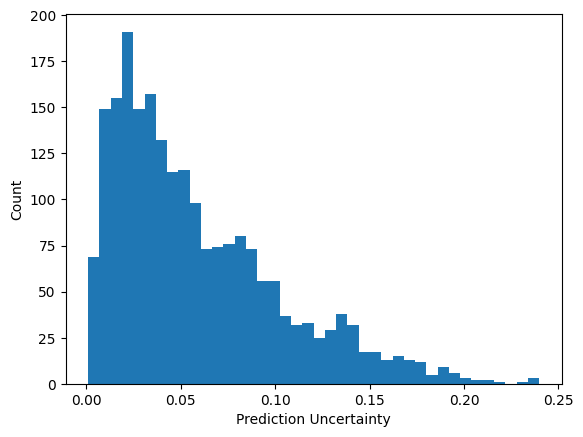

In [205]:
plt.hist(results["uncertainty"], bins=40)
plt.xlabel("Prediction Uncertainty")
plt.ylabel("Count")
plt.show()


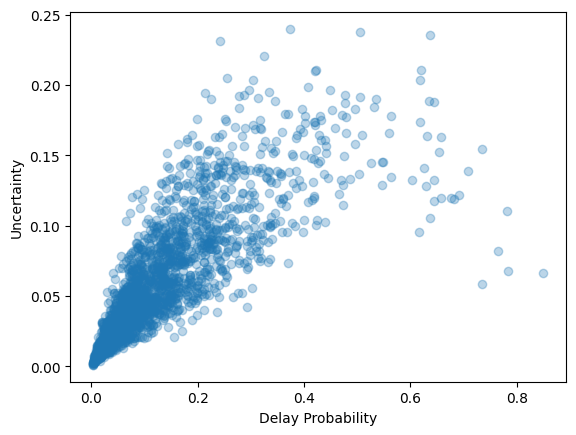

In [206]:
plt.scatter(results["delay_prob"], results["uncertainty"], alpha=0.3)
plt.xlabel("Delay Probability")
plt.ylabel("Uncertainty")
plt.show()


In [215]:
results.sort_values("uncertainty", ascending=False).head(10)


,hour,day_of_week,is_weekend,carrier_avg_delay,route_avg_delay,weather_severity,rolling_weather,congestion_score,rolling_origin_delay,prev_delay,delay_prob,uncertainty,actual
10158,9,0,0,14.661911,22.557143,4.85,7.04075,0.594012,4.285,6.0,0.373263,0.239805,0
10108,15,0,0,42.635359,23.660000,4.85,7.90325,0.795490,7.685,53.0,0.505034,0.237841,0
8966,21,3,0,3.589113,11.034286,28.90,28.90000,0.724893,7.490,345.0,0.636309,0.235817,0
10324,19,0,0,7.903481,19.000000,4.85,4.85000,0.578174,13.905,-13.0,0.240960,0.230922,1
10282,21,0,0,3.589113,-9.202186,4.85,4.90175,0.523200,13.120,105.0,0.324376,0.220242,0
8928,19,3,0,7.903481,19.000000,28.90,28.90000,0.907006,6.775,44.0,0.619702,0.210570,0
8712,17,3,0,14.661911,5.065574,28.90,43.09400,0.789410,9.895,144.0,0.422981,0.210405,1
8941,19,3,0,3.589113,3.430233,28.90,28.90000,0.728861,6.265,-5.0,0.420093,0.209729,0
10134,22,0,0,14.661911,21.177778,4.85,7.45475,0.349060,4.065,76.0,0.254516,0.205162,0
10575,20,1,0,42.635359,11.212121,9.90,7.85475,0.578174,22.635,160.0,0.617999,0.203667,1


- This is what your planner will consume

In [216]:
def risk_score(row):
    return row["delay_prob"] + row["uncertainty"]

results["risk"] = results.apply(risk_score, axis=1)

results[["delay_prob","uncertainty","risk","actual"]].head(10)


,delay_prob,uncertainty,risk,actual
8654,0.764168,0.082280,0.846449,0
8655,0.049076,0.013913,0.062989,0
8656,0.153488,0.049495,0.202983,1
8657,0.198846,0.129725,0.328572,0
8658,0.658188,0.119606,0.777795,0
8659,0.272352,0.085378,0.357729,1
8660,0.562705,0.134539,0.697245,1
8661,0.239077,0.150507,0.389585,1
8662,0.248861,0.126134,0.374995,1
8663,0.218556,0.087556,0.306112,0


## SHAP explanations

- Load model & data

In [220]:
import pandas as pd
import joblib
import shap
import numpy as np

from sklearn.metrics import confusion_matrix

# Load gold features
df = pd.read_csv("data/gold/jfk_delay_features_v2.csv")

X = df.drop(columns=["is_delayed"])
y = df["is_delayed"]

split = int(len(X)*0.8)

X_train = X.iloc[:split]
y_train = y.iloc[:split]

X_test = X.iloc[split:]
y_test = y.iloc[split:]

# Load trained model
model = joblib.load("models/champion_delay_model.pkl")

print("Train:", len(X_train))
print("Test:", len(X_test))


Train: 8654
Test: 2164


- Global feature importance (most important plot)

- SHAP Explainer

ExactExplainer explainer: 2165it [42:59,  1.20s/it]                              


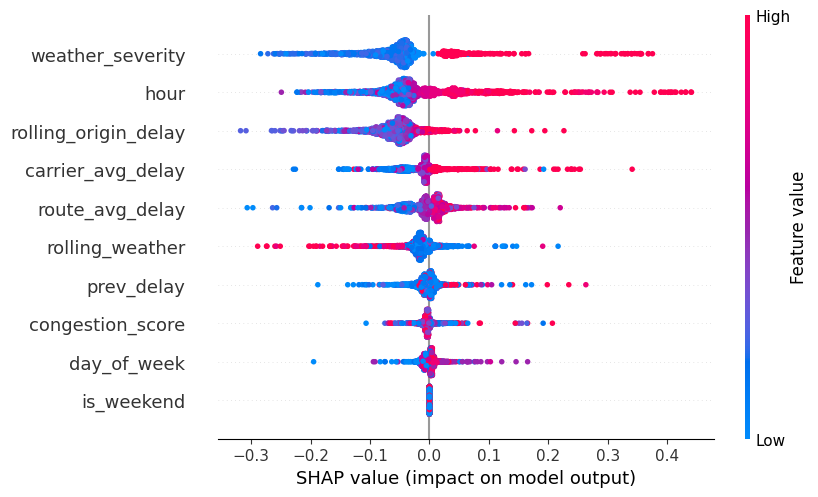

In [223]:
import shap

# Use full pipeline (not raw xgb)
explainer = shap.Explainer(model.predict, X_train)

shap_values = explainer(X_test)

shap.plots.beeswarm(shap_values)


- Each dot is one flight
- Weather Severity matters most
- RIGHT = pushes toward delay
- LEFT = pushes toward on-time
- Red = HIGH feature value (heavy rain / strong wind in weather severity)
- Blue = LOW feature value (calm weather)
- red dots on the RIGHT - High weather severity → pushes delay up (for weather severity)
- blue dots on the LEFT - Low weather severity → pushes delay down

- Single flight explanation

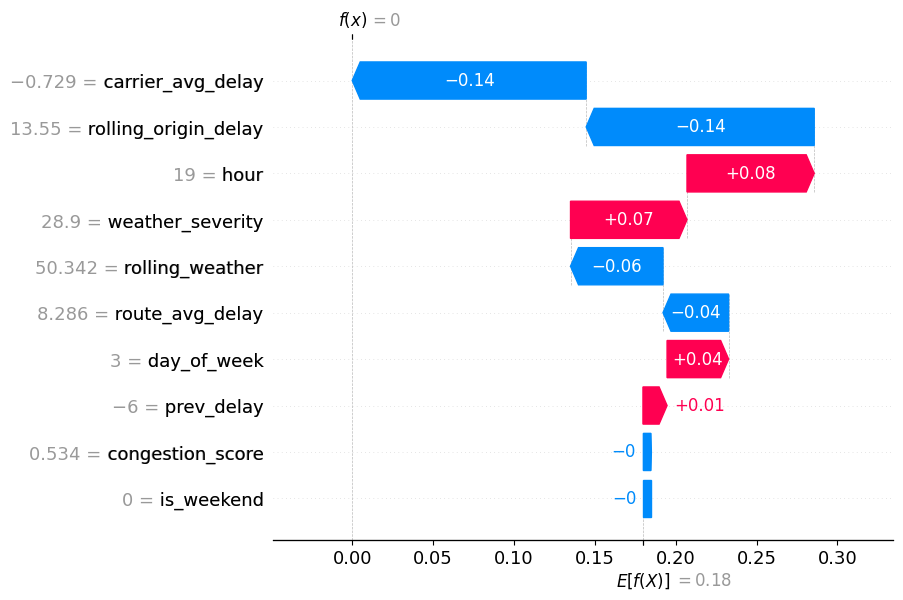

In [225]:
i = 10

shap.plots.waterfall(shap_values[i])


- This waterfall plot shows how each feature individually pushed the delay prediction up or down from the baseline, explaining why this flight ended up with a moderate delay risk.

- Bar chart

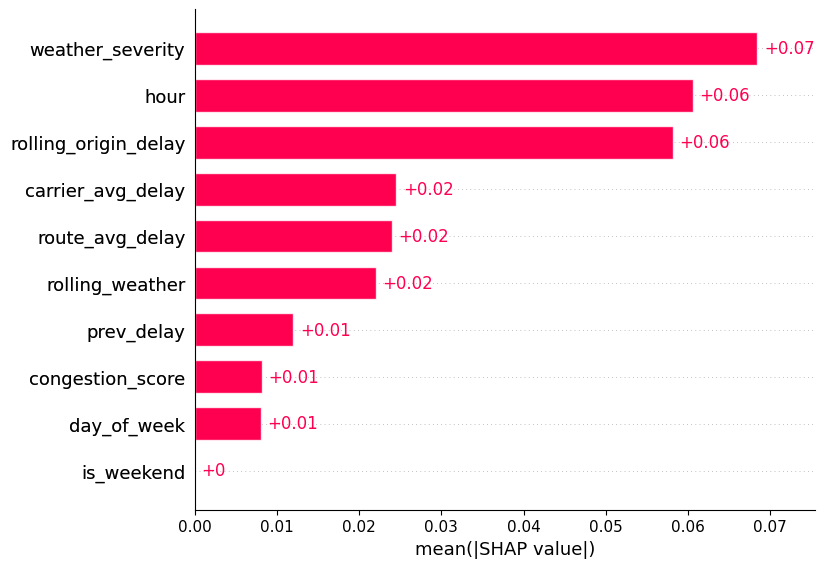

In [226]:
shap.plots.bar(shap_values)


- Create prediction table for failure analysis

In [227]:
probs = model.predict_proba(X_test)[:,1]
preds = (probs > 0.5).astype(int)

analysis = X_test.copy()
analysis["actual"] = y_test.values
analysis["pred"] = preds
analysis["prob"] = probs

analysis.head()


,hour,day_of_week,is_weekend,carrier_avg_delay,route_avg_delay,weather_severity,rolling_weather,congestion_score,rolling_origin_delay,prev_delay,actual,pred,prob
8654,21,3,0,14.661911,12.797153,28.9,51.852,0.534283,15.005,29.0,0,1,0.762809
8655,7,3,0,3.589113,7.676829,28.9,51.701,0.534283,15.020,-4.0,0,0,0.054161
8656,12,3,0,3.589113,20.909502,28.9,51.550,0.534283,15.035,-7.0,1,0,0.184326
8657,9,3,0,14.661911,19.500000,28.9,51.399,0.534283,14.910,11.0,0,0,0.128494
8658,19,3,0,14.661911,15.204918,28.9,51.248,0.534283,14.900,-8.0,0,1,0.608579


- Confusion matrix

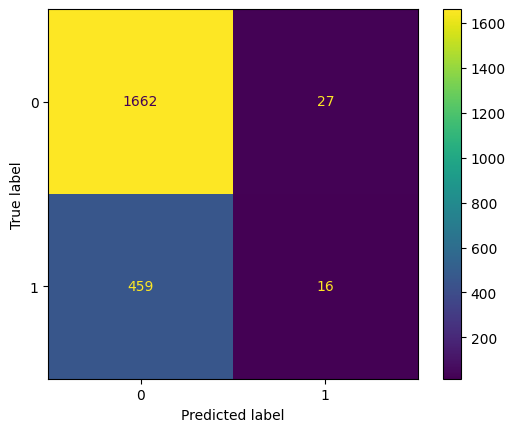

In [228]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, preds)
plt.show()


- Top-left: 1662 - Actual = 0 (not delayed), Predicted = 0 (not delayed)
- Top-right: 27 - Actual = 0 (not delayed), Predicted = 1 (delayed)
- Bottom-left: 459 - Actual = 1 (delayed), Predicted = 0 (not delayed)
- Bottom-right: 16 - Actual = 1 (delayed), Predicted = 1 (delayed)

- Inspect failures

- False positives (predicted delay, actually on-time)

In [229]:
false_pos = analysis[(analysis["pred"]==1) & (analysis["actual"]==0)]
false_pos.head()


,hour,day_of_week,is_weekend,carrier_avg_delay,route_avg_delay,weather_severity,rolling_weather,congestion_score,rolling_origin_delay,prev_delay,actual,pred,prob
8654,21,3,0,14.661911,12.797153,28.9,51.852,0.534283,15.005,29.0,0,1,0.762809
8658,19,3,0,14.661911,15.204918,28.9,51.248,0.534283,14.900,-8.0,0,1,0.608579
8681,20,3,0,42.635359,23.660000,28.9,47.775,0.595499,11.910,7.0,0,1,0.543366
8690,21,3,0,-0.728966,11.034286,28.9,46.416,0.595499,10.145,14.0,0,1,0.505279
8693,21,3,0,14.661911,13.564103,28.9,45.963,0.789410,10.095,-8.0,0,1,0.677649


- False negatives (predicted on-time, actually delayed)

In [230]:
false_neg = analysis[(analysis["pred"]==0) & (analysis["actual"]==1)]
false_neg.head()


,hour,day_of_week,is_weekend,carrier_avg_delay,route_avg_delay,weather_severity,rolling_weather,congestion_score,rolling_origin_delay,prev_delay,actual,pred,prob
8656,12,3,0,3.589113,20.909502,28.9,51.550,0.534283,15.035,-7.0,1,0,0.184326
8659,17,3,0,3.589113,4.770053,28.9,51.097,0.534283,13.965,-2.0,1,0,0.160800
8660,17,3,0,14.661911,8.286082,28.9,50.946,0.534283,13.540,-1.0,1,0,0.421448
8661,17,3,0,-0.728966,-1.311927,28.9,50.795,0.534283,13.605,-2.0,1,0,0.224057
8662,12,3,0,14.661911,12.797153,28.9,50.644,0.534283,13.550,3.0,1,0,0.275069


- Why did failures happen?

In [231]:
false_neg[[
    "rolling_origin_delay",
    "congestion_score",
    "route_avg_delay",
    "carrier_avg_delay",
    "rolling_weather"
]].mean()


rolling_origin_delay    10.228203
congestion_score         0.619134
route_avg_delay          6.108133
carrier_avg_delay        6.873264
rolling_weather         12.932446
dtype: float64

In [232]:
analysis[[
    "rolling_origin_delay",
    "congestion_score",
    "route_avg_delay",
    "carrier_avg_delay",
    "rolling_weather"
]].mean()


rolling_origin_delay     8.793704
congestion_score         0.628091
route_avg_delay          5.813300
carrier_avg_delay        5.999453
rolling_weather         13.355096
dtype: float64

In [4]:
import pandas as pd
import joblib
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error

from xgboost import XGBRegressor


def main():

    df = pd.read_csv("data/gold/jfk_congestion_forecast_features.csv")

    X = df.drop(columns=["future_congestion"])
    y = df["future_congestion"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, shuffle=False, test_size=0.2
    )

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model", XGBRegressor(
            max_depth=4,
            n_estimators=300,
            learning_rate=0.05
        ))
    ])

    pipe.fit(X_train, y_train)

    preds = pipe.predict(X_test)
    mae = mean_absolute_error(y_test, preds)

    print("Congestion MAE:", mae)

    Path("models").mkdir(exist_ok=True)
    joblib.dump(pipe, "models/congestion_forecaster.pkl")

    print("Saved congestion forecaster")
    
    baseline_preds = X_test["rolling_congestion"]
    baseline_mae = mean_absolute_error(y_test, baseline_preds)

    print("Baseline MAE:", baseline_mae)


if __name__ == "__main__":
    main()


Congestion MAE: 0.0335730076625266
Saved congestion forecaster
Baseline MAE: 0.10090199329131815


In [ ]:
baseline_preds = X_test["rolling_congestion"]
baseline_mae = mean_absolute_error(y_test, baseline_preds)

print("Baseline MAE:", baseline_mae)

NameError: name 'X_test' is not defined